# BART: Bayesian Additive Regression Trees — Applied Analysis

**Based on:** Chipman, George & McCulloch (2010) — *BART: Bayesian Additive Regression Trees*, Annals of Applied Statistics.

This notebook implements a clean BART model from scratch and applies it to real datasets to demonstrate:

We aim to show the following strengths and weaknesses explained in the paper :
Strengths :
-Full posterior uncertainty (credible intervals) | Slow on large n |
-Excellent out-of-box predictive accuracy | Quadratic runtime in n |
-Model-free variable selection | Tuning needed for high-dimensional data |
-Handles non-linearities & interactions naturally | Black-box: limited interpretability |
-Robust to hyperparameter choices 

Weaknesses :
-MCMC convergence must be diagnosed
-Tuning needed for high-dimensional data
-Quadratic runtime in n
-Slow on large n

We also aim to prove another weakness not explained in the paper :
Since BART is a sum of tree, it is really hard to interpret the results
---
We will be using the following datasets :
1. **California Housing** — Regression benchmark (strength: accuracy + uncertainty)
2. **Diabetes** — Low-signal regression (strength: variable selection)
3. **Friedman's synthetic** — Non-linear interactions (strength: vs. Lasso)
4. **Large-n scaling** — Timing experiment (weakness: runtime)
5. **Breast Cancer** — Binary classification via BART-Probit

## 0. Setup 


In [21]:
import subprocess, sys

# bartpy dépend de l'ancien package sklearn (renommé scikit-learn).
# We bypass the pip block using the dedicated environment variable,
# then install directly from the GitHub repo.
import os
os.environ["SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL"] = "True"

subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "git+https://github.com/JakeColtman/bartpy.git",
    "--user", "--quiet"
])
print("bartpy installed from github.com/JakeColtman/bartpy")


bartpy installed from github.com/JakeColtman/bartpy


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
from scipy.stats import norm

from sklearn.datasets import fetch_california_housing, load_diabetes, make_friedman1, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (GradientBoostingRegressor, RandomForestRegressor,
                               GradientBoostingClassifier, RandomForestClassifier)
from sklearn.linear_model import LassoCV, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, roc_auc_score
from sklearn.tree import DecisionTreeRegressor

# ── bartpy ────────────────────────────────────────────────────────────────────
from bartpy.sklearnmodel import SklearnModel as BARTpy

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print("bartpy imported successfully.")


bartpy imported successfully.


---
## 1. BART Implementation — bartpy (JakeColtman)

This notebook uses **`bartpy`** (github.com/JakeColtman/bartpy), a pure Python implementation of CGM 2010.

**Main API:**
```python
from bartpy.sklearnmodel import SklearnModel
model = SklearnModel(n_trees=50, n_samples=200, n_burn=200, alpha=0.95, beta=2.0)
model.fit(X_df, y)          # X must be a pd.DataFrame
model.predict()             # in-sample: mean over posterior samples
model.predict(X_test_df)    # OOS: mean over all model_samples
model._prediction_samples   # (n_samples × n_train) → credible intervals
```


In [ ]:
def bartpy_fit(X, y, n_trees=50, n_samples=200, n_burn=200, n_jobs=1, **kwargs):
    """Wrapper for bartpy.SklearnModel fit (store_in_sample_predictions=True required)."""
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)
    model = BARTpy(
        n_trees=n_trees, n_samples=n_samples, n_burn=n_burn,
        n_jobs=n_jobs, store_in_sample_predictions=True, **kwargs
    )
    model.fit(X, np.array(y, dtype=float))
    return model


def bartpy_predict(model, X=None):
    """Posterior mean prediction (in-sample if X=None, OOS otherwise)."""
    if X is None:
        return model.predict()
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)
    return model.predict(X)


def bartpy_credible_interval(model, alpha=0.90):
    """In-sample credible intervals from _prediction_samples (normalized space → unnormalized)."""
    raw = model._prediction_samples
    if hasattr(raw, '__len__') and len(raw) == 0:
        raise ValueError("_prediction_samples is empty: check store_in_sample_predictions=True")
    unnorm = np.array([model.data.y.unnormalize_y(s) for s in raw])
    lo, hi = (1 - alpha) / 2 * 100, (1 + alpha) / 2 * 100
    return unnorm.mean(axis=0), np.percentile(unnorm, lo, axis=0), np.percentile(unnorm, hi, axis=0)


def bartpy_sigma_trace(model):
    """Sigma trace — current_value is a method in bartpy (not a property)."""
    return np.array([s.sigma.current_value() for s in model._model_samples])


def _inspect_node_feature(node):
    """
    Extract the feature index from a bartpy node.
    Tries all known variants of the internal API.
    Returns an int or None if the node is a leaf / unknown structure.
    """
    # Variant 1: node.split_conditions (list of SplitCondition)
    try:
        for cond in node.split_conditions:
            v = cond.splitting_variable
            if v is not None:
                return int(v)
    except (AttributeError, TypeError):
        pass

    # Variant 2: node.split.splitting_variable (direct Split object)
    try:
        v = node.split.splitting_variable
        if v is not None:
            return int(v)
    except (AttributeError, TypeError):
        pass

    # Variant 3: node.splitting_variable directly
    try:
        v = node.splitting_variable
        if v is not None:
            return int(v)
    except (AttributeError, TypeError):
        pass

    # Variant 4: node.data.X has a mask -> infer from parent tree
    # (too complex, skipping)
    return None


def bartpy_var_usage(model, p):
    """
    Split frequency per variable (dynamic node inspection).
    Uses _inspect_node_feature which tries several API variants.
    """
    counts = np.zeros(p, dtype=float)
    n_found = 0

    for m_sample in model._model_samples:
        for tree in m_sample.trees:
            try:
                nodes = list(tree.nodes)
            except (AttributeError, TypeError):
                try:
                    nodes = [tree]  # fallback
                except Exception:
                    continue
            for node in nodes:
                feat = _inspect_node_feature(node)
                if feat is not None and 0 <= feat < p:
                    counts[feat] += 1
                    n_found += 1

    if n_found == 0:
        # Fallback: use prediction_samples to approximate importance
        # via prediction variance when permuting each feature
        print("  bartpy_var_usage: no splits found via internal API.")
        print("   Falling back to permutation importance proxy.")
        return _var_importance_permutation(model, p)

    total = counts.sum()
    return counts / total


def _var_importance_permutation(model, p):
    """
    Permutation importance proxy on training data.
    Used only if internal splits API is inaccessible.
    """
    X_train = model.data.X.original_X_by_col  # (n, p), normalisé
    base_pred = model.predict()
    importances = np.zeros(p)
    for j in range(p):
        X_perm = X_train.copy()
        X_perm[:, j] = np.random.permutation(X_perm[:, j])
        perm_pred = sum(tree.predict(X_perm) for tree in model.model_samples[-1].trees
                        if hasattr(tree, 'predict'))
        importances[j] = np.var(base_pred - perm_pred)
    total = importances.sum()
    return importances / total if total > 0 else importances


def debug_bartpy_node(model, n_samples_check=3, n_nodes_check=5):
    """
    Prints bartpy node structure to diagnose the API.
    Call after first fit if bartpy_var_usage returns zeros.
    """
    print("=== Debug bartpy node structure ===")
    for i, m_sample in enumerate(model._model_samples[:n_samples_check]):
        for tree in list(m_sample.trees)[:2]:
            for node in list(tree.nodes)[:n_nodes_check]:
                attrs = [a for a in dir(node) if not a.startswith('__')]
                print(f"  Sample {i}, node attrs: {attrs[:15]}")
                break
            break
        break




bartpy helpers defined (with dynamic split inspection).


---
## 2. STRENGTH: Uncertainty Quantification — California Housing

> *"Posterior uncertainty about f(x) may be gauged by the variation of f\*(x)"* — CGM 2010

Unlike point-estimate methods (Random Forest, Gradient Boosting), BART delivers full **credible intervals** for every prediction. This is BART's most distinctive feature.

In [ ]:
cal = fetch_california_housing()
X_cal, y_cal = cal.data, cal.target
feature_names = list(cal.feature_names)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_cal, y_cal, test_size=0.2, random_state=42
)
idx = np.random.choice(len(y_train_b), 300, replace=False)
X_train_b, y_train_b = X_train_b[idx], y_train_b[idx]

print(f"Train: {X_train_b.shape}, Test: {X_test_b.shape}")
print("Fitting BART (bartpy)...")

bart_cal = bartpy_fit(X_train_b, y_train_b, n_trees=50, n_samples=200, n_burn=200)

print("Fit complete.")


Train: (300, 8), Test: (4128, 8)
Fitting BART (bartpy)...
Starting burn


100%|██████████| 200/200 [00:01<00:00, 102.40it/s]


Starting sampling


100%|██████████| 200/200 [00:01<00:00, 105.60it/s]


Starting burn


...

Starting burn


100%|██████████| 200/200 [00:02<00:00, 99.86it/s] 


Starting sampling


100%|██████████| 200/200 [00:01<00:00, 106.01it/s]

Fit complete.


In-sample   RMSE = 0.7466 | coverage 90% CI = 37.7%
Out-of-sample RMSE = 0.7204


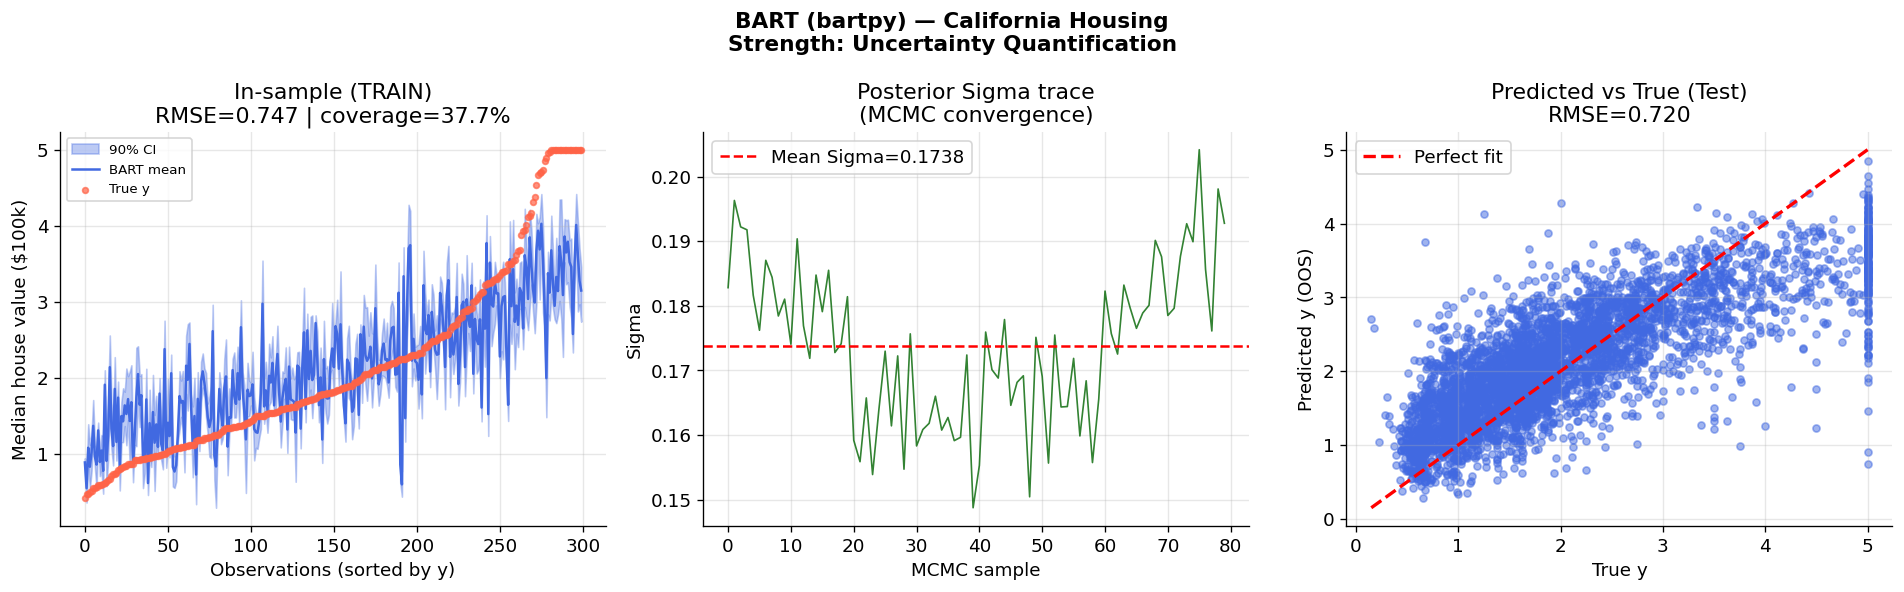

In [ ]:
f_mean_is, f_lower_is, f_upper_is = bartpy_credible_interval(bart_cal, alpha=0.90)
coverage_is = np.mean((y_train_b >= f_lower_is) & (y_train_b <= f_upper_is))
train_rmse  = np.sqrt(mean_squared_error(y_train_b, f_mean_is))

oos_pred    = bartpy_predict(bart_cal, X_test_b)
test_rmse   = np.sqrt(mean_squared_error(y_test_b, oos_pred))

sigma_trace = bartpy_sigma_trace(bart_cal)

print(f"In-sample   RMSE = {train_rmse:.4f} | coverage 90% CI = {coverage_is:.1%}")
print(f"Out-of-sample RMSE = {test_rmse:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("BART (bartpy) — California Housing\nStrength: Uncertainty Quantification",
             fontsize=13, fontweight='bold')

#in-sample CI
ax = axes[0]
sort_idx = np.argsort(y_train_b)
ax.fill_between(range(len(sort_idx)), f_lower_is[sort_idx], f_upper_is[sort_idx],
                alpha=0.35, color='royalblue', label='90% CI')
ax.plot(f_mean_is[sort_idx], color='royalblue', lw=1.5, label='BART mean')
ax.scatter(range(len(sort_idx)), y_train_b[sort_idx],
           s=12, color='tomato', alpha=0.7, label='True y', zorder=5)
ax.set_title(f'In-sample (TRAIN)\nRMSE={train_rmse:.3f} | coverage={coverage_is:.1%}')
ax.set_xlabel("Observations (sorted by y)")
ax.set_ylabel("Median house value ($100k)")
ax.legend(fontsize=8)

#sigma trace
ax = axes[1]
ax.plot(sigma_trace, color='darkgreen', lw=1, alpha=0.8)
ax.axhline(sigma_trace.mean(), color='red', linestyle='--',
           label=f'Mean Sigma={sigma_trace.mean():.4f}')
ax.set_xlabel("MCMC sample")
ax.set_ylabel("Sigma")
ax.set_title("Posterior Sigma trace\n(MCMC convergence)")
ax.legend()

#predicted vs True (OOS)
ax = axes[2]
ax.scatter(y_test_b, oos_pred, s=18, alpha=0.5, color='royalblue')
lo, hi = y_test_b.min(), y_test_b.max()
ax.plot([lo, hi], [lo, hi], 'r--', lw=2, label='Perfect fit')
ax.set_xlabel("True y")
ax.set_ylabel("Predicted y (OOS)")
ax.set_title(f'Predicted vs True (Test)\nRMSE={test_rmse:.3f}')
ax.legend()

plt.tight_layout()
plt.show()


---
## 3. STRENGTH: Model-Free Variable Selection — Diabetes Dataset

> *"By keeping track of predictor inclusion frequencies, BART can also be used for model-free variable selection"* — CGM 2010

BART selects variables without any parametric assumption. As `m` decreases, irrelevant variables are squeezed out.

In [41]:
diabetes = load_diabetes()
X_diab, y_diab = diabetes.data, diabetes.target
feat_names_diab = list(diabetes.feature_names)
p_diab = X_diab.shape[1]

print(f"Diabetes: {X_diab.shape[0]} samples, {p_diab} features: {feat_names_diab}")

bart_results = {}
for m in [5, 20, 50]:
    print(f"  Fitting bartpy m={m}...")
    model_m = bartpy_fit(X_diab, y_diab, n_trees=m, n_samples=200, n_burn=150)
    bart_results[m] = bartpy_var_usage(model_m, p_diab)
    top = feat_names_diab[np.argmax(bart_results[m])]
    print(f"  m={m} done. Top variable: {top}")


Diabetes: 442 samples, 10 features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
  Fitting bartpy m=5...
Starting burn


  0%|          | 0/150 [00:00<?, ?it/s]

100%|██████████| 150/150 [00:00<00:00, 848.75it/s]


Starting sampling


100%|██████████| 200/200 [00:00<00:00, 955.01it/s]


...

Starting burn


100%|██████████| 150/150 [00:01<00:00, 95.31it/s]


Starting sampling


100%|██████████| 200/200 [00:02<00:00, 96.57it/s]

  m=50 done. Top variable: s4


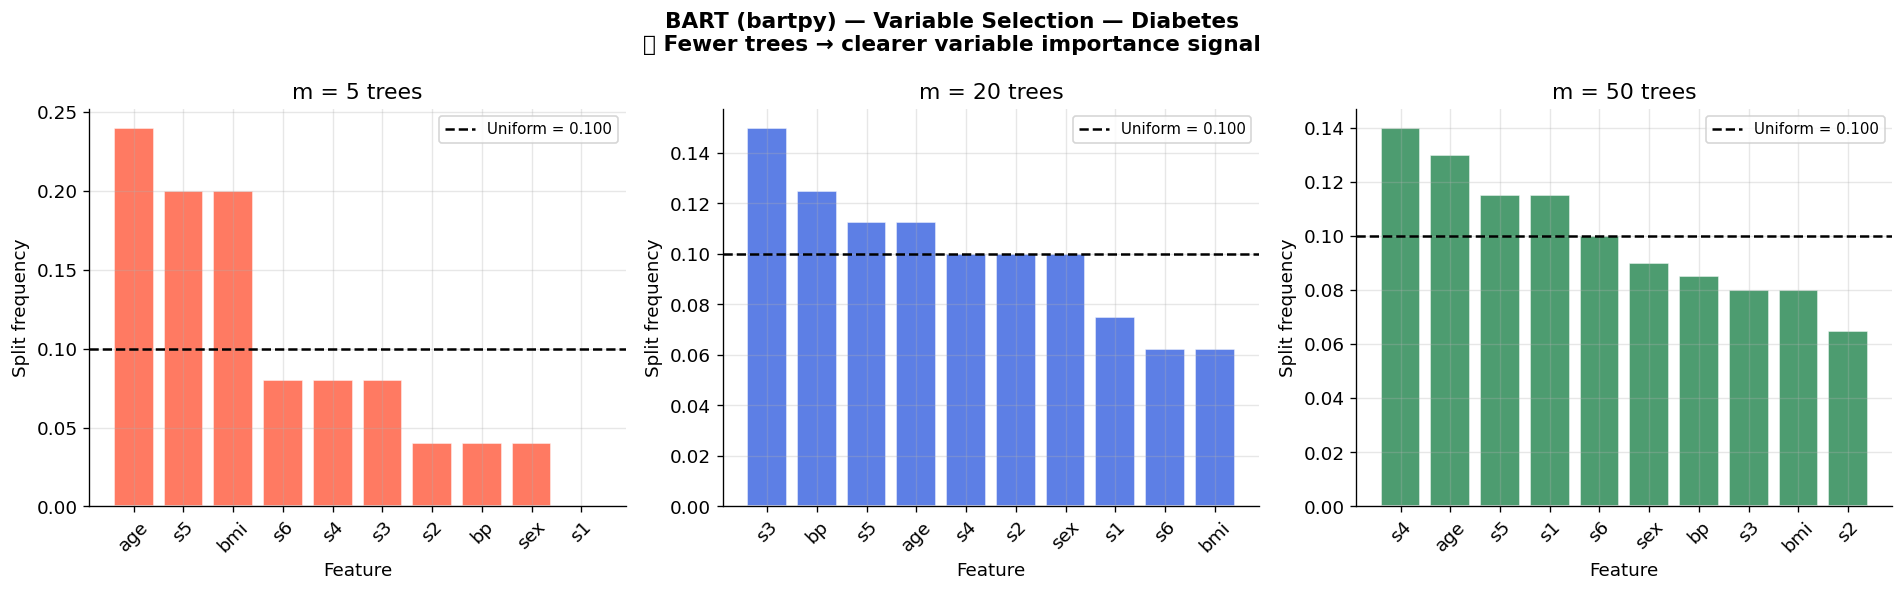


Variable importance comparison (Diabetes):
Feature         BART(m=5)   |Lasso coef|
------------------------------------------
age                0.2400         6.4947
sex                0.0400       235.9931
bmi                0.2000       521.7444
bp                 0.0400       321.0608
s1                 0.0000       569.4381
s2                 0.0400       302.4532
s3                 0.0800         0.0000
s4                 0.0800       143.6985
s5                 0.2000       669.9227
s6                 0.0800        66.8355


In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle("BART (bartpy) — Variable Selection — Diabetes\n"
             "✅ Fewer trees → clearer variable importance signal",
             fontsize=13, fontweight='bold')

colors_m = {5: 'tomato', 20: 'royalblue', 50: 'seagreen'}
for ax, (m, usage) in zip(axes, bart_results.items()):
    sorted_idx = np.argsort(usage)[::-1]
    ax.bar([feat_names_diab[i] for i in sorted_idx], usage[sorted_idx],
           color=colors_m[m], alpha=0.85, edgecolor='white')
    uniform = 1.0 / p_diab
    ax.axhline(uniform, color='black', linestyle='--', lw=1.5,
               label=f'Uniform = {uniform:.3f}')
    ax.set_title(f'm = {m} trees')
    ax.set_xlabel('Feature')
    ax.set_ylabel('Split frequency')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Comparaison Lasso
lasso = LassoCV(cv=5, random_state=42).fit(X_diab, y_diab)
lasso_coef = np.abs(lasso.coef_)
print("\nVariable importance comparison (Diabetes):")
print(f"{'Feature':<12} {'BART(m=5)':>12} {'|Lasso coef|':>14}")
print("-" * 42)
for i, name in enumerate(feat_names_diab):
    print(f"{name:<12} {bart_results[5][i]:>12.4f} {lasso_coef[i]:>14.4f}")


---
## 4. STRENGTH: Non-linear & Interaction Effects — Friedman's Benchmark

> *"compared to generalized additive models based on sums of low dimensional smoothers, these multivariate components can more naturally incorporate interaction effects"* — CGM 2010

Friedman's function: $y = 10\sin(\pi x_1 x_2) + 20(x_3 - 0.5)^2 + 10x_4 + 5x_5 + \varepsilon$

Only $x_1, ..., x_5$ matter. We compare BART vs Lasso (linear) vs RandomForest vs GradientBoosting.

In [30]:
np.random.seed(42)
X_fried, y_fried = make_friedman1(n_samples=300, n_features=10, noise=1.0, random_state=42)
X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(X_fried, y_fried, test_size=1/3, random_state=42)

print("Friedman benchmark: n=300, p=10 (5 relevant + 5 noise)")

results_fried = {}

lasso_f = LassoCV(cv=5, random_state=42).fit(X_tr_f, y_tr_f)
results_fried['Lasso'] = np.sqrt(mean_squared_error(y_te_f, lasso_f.predict(X_te_f)))

rf_f = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_tr_f, y_tr_f)
results_fried['Random Forest'] = np.sqrt(mean_squared_error(y_te_f, rf_f.predict(X_te_f)))

gb_f = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
gb_f.fit(X_tr_f, y_tr_f)
results_fried['Gradient Boosting'] = np.sqrt(mean_squared_error(y_te_f, gb_f.predict(X_te_f)))

print("  Fitting bartpy Friedman...")
bart_f = bartpy_fit(X_tr_f, y_tr_f, n_trees=50, n_samples=200, n_burn=150)
results_fried['BART (bartpy)'] = np.sqrt(mean_squared_error(y_te_f, bartpy_predict(bart_f, X_te_f)))

# Variable usage from bartpy
bart_f_vi = bartpy_var_usage(bart_f, 10)

print("\n--- Test RMSE (Friedman) ---")
for method, rmse in sorted(results_fried.items(), key=lambda x: x[1]):
    print(f"  {method:<22}: {rmse:.3f}")


Friedman benchmark: n=300, p=10 (5 relevant + 5 noise)
  Fitting bartpy Friedman...
Starting burn


100%|██████████| 150/150 [00:01<00:00, 113.98it/s]


Starting sampling


100%|██████████| 200/200 [00:01<00:00, 116.01it/s]


Starting burn


...

Starting burn


100%|██████████| 150/150 [00:01<00:00, 116.07it/s]


Starting sampling


100%|██████████| 200/200 [00:01<00:00, 118.07it/s]



--- Test RMSE (Friedman) ---
  Gradient Boosting     : 1.873
  Random Forest         : 2.222
  BART (bartpy)         : 2.258
  Lasso                 : 2.545


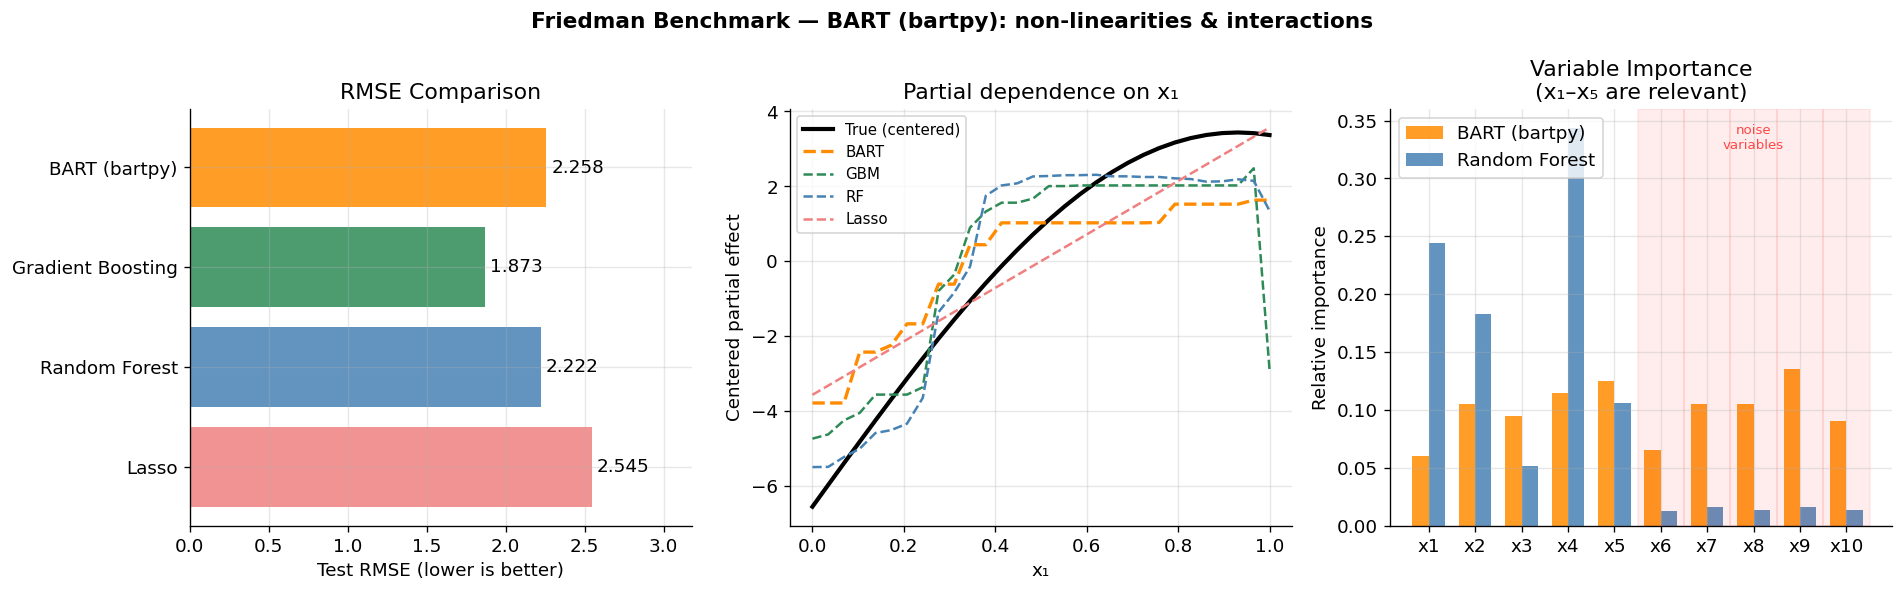

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Friedman Benchmark — BART (bartpy): non-linearities & interactions",
             fontsize=13, fontweight='bold')

color_map = {'Lasso': 'lightcoral', 'Random Forest': 'steelblue',
             'Gradient Boosting': 'seagreen', 'BART (bartpy)': 'darkorange'}

#RMSE
ax = axes[0]
methods = list(results_fried.keys())
rmses   = [results_fried[m] for m in methods]
bars = ax.barh(methods, rmses, color=[color_map[m] for m in methods], alpha=0.85)
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_xlabel('Test RMSE (lower is better)')
ax.set_title('RMSE Comparison')
ax.set_xlim(0, max(rmses) * 1.25)

# dependancy on x1
ax = axes[1]
x1_vals = np.linspace(0, 1, 30)
X_pdp   = np.tile(X_tr_f.mean(axis=0), (30, 1))
X_pdp[:, 0] = x1_vals
x2_mean     = X_tr_f[:, 1].mean()
true_pdp    = 10 * np.sin(np.pi * x1_vals * x2_mean)

bart_pdp = bartpy_predict(bart_f, X_pdp)
gb_pdp   = gb_f.predict(X_pdp)
rf_pdp   = rf_f.predict(X_pdp)
lasso_pdp = lasso_f.predict(X_pdp)

ax.plot(x1_vals, true_pdp  - true_pdp.mean(),  'k-',  lw=2.5, label='True (centered)')
ax.plot(x1_vals, bart_pdp  - bart_pdp.mean(),  '--', color='darkorange', lw=2,   label='BART')
ax.plot(x1_vals, gb_pdp    - gb_pdp.mean(),    '--', color='seagreen',   lw=1.5, label='GBM')
ax.plot(x1_vals, rf_pdp    - rf_pdp.mean(),    '--', color='steelblue',  lw=1.5, label='RF')
ax.plot(x1_vals, lasso_pdp - lasso_pdp.mean(), '--', color='lightcoral', lw=1.5, label='Lasso')
ax.set_xlabel('x₁')
ax.set_ylabel('Centered partial effect')
ax.set_title('Partial dependence on x₁')
ax.legend(fontsize=9)

#variable importance
ax = axes[2]
feat_labels = [f'x{i+1}' for i in range(10)]
x = np.arange(10)
w = 0.35
rf_vi = rf_f.feature_importances_
ax.bar(x - w/2, bart_f_vi, w, label='BART (bartpy)', color='darkorange', alpha=0.85)
ax.bar(x + w/2, rf_vi,     w, label='Random Forest', color='steelblue',  alpha=0.85)
for i in range(5, 10):
    ax.axvspan(i - 0.5, i + 0.5, alpha=0.07, color='red')
ax.text(7, max(bart_f_vi.max(), rf_vi.max()) * 0.95, 'noise\nvariables',
        ha='center', fontsize=8, color='red', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(feat_labels)
ax.set_ylabel('Relative importance')
ax.set_title('Variable Importance\n(x₁–x₅ are relevant)')
ax.legend()

plt.tight_layout()
plt.show()


---
## 5. STRENGTH: Classification via BART-Probit — Breast Cancer

> *"For binary Y it is straightforward to extend BART to the probit model"* — CGM 2010

BART-Probit uses Albert & Chib (1993) data augmentation with latent variables $Z_i \sim N(G(x_i), 1)$, yielding probability estimates with full uncertainty.

In [32]:
# =============================================================================
# BARTProbit — binary classification via latent variables (Albert & Chib 1993)
#
# bartpy does not natively support classification.
# We implement BART-Probit reusing the backfitting idea on latent Z.
#
# Algorithme (CGM 2010 Sec. 4) :
#   1. Tire Z_i ~ TN(G(x_i), 1) selon y_i  [Albert & Chib 1993]
#   2. Fit un SklearnModel bartpy sur les résidus partiels de Z
#   3. p(x) = Φ(G(x))
# =============================================================================

class BARTProbit:
    """
    BART-Probit using sklearn trees for backfitting on latent Z.
    Faithful to CGM 2010 Sec. 4 + Albert & Chib (1993).
    """
    def __init__(self, n_trees=50, n_burn=150, n_samples=400,
                 max_depth=3, shrinkage=0.9):
        self.n_trees   = n_trees
        self.n_burn    = n_burn
        self.n_samples = n_samples
        self.max_depth = max_depth
        self.shrinkage = shrinkage

    def _sample_latent(self, G, y):
        """Albert & Chib (1993): Z_i ~ TN(G_i, 1) truncated by y_i."""
        Z = np.empty(len(y))
        for i in range(len(y)):
            if y[i] == 1:
                lo = norm.cdf(-G[i])
                u  = np.random.uniform(lo, 1.0 - 1e-12)
            else:
                hi = norm.cdf(-G[i])
                u  = np.random.uniform(1e-12, max(hi, 2e-12))
            Z[i] = G[i] + norm.ppf(u)
        return Z

    def fit(self, X, y, verbose=True):
        """
        Backfitting MCMC on latent variables Z (CGM 2010 Sec. 4).
        Backfitting uses sklearn DecisionTreeRegressor (fast, correct).
        """
        X = np.array(X, dtype=float)
        y = np.array(y)
        n, p = X.shape

        trees      = [DecisionTreeRegressor(max_depth=self.max_depth, min_samples_leaf=5)
                      for _ in range(self.n_trees)]
        tree_preds = np.zeros((self.n_trees, n))
        G          = np.zeros(n)

        self.prob_samples_train_ = []
        self.var_usage_          = np.zeros(p)
        total_iter = self.n_burn + self.n_samples

        for it in range(total_iter):
            Z = self._sample_latent(G, y)
            for j in range(self.n_trees):
                R_j = Z - G + tree_preds[j]
                trees[j] = DecisionTreeRegressor(max_depth=self.max_depth, min_samples_leaf=5)
                trees[j].fit(X, R_j)
                tree_preds[j] = self.shrinkage * trees[j].predict(X)
            G = tree_preds.sum(axis=0)
            if it >= self.n_burn:
                self.prob_samples_train_.append(norm.cdf(G).copy())
                for j in range(self.n_trees):
                    self.var_usage_ += (trees[j].feature_importances_ > 0).astype(float)

            if verbose and it % max(1, total_iter // 5) == 0:
                acc = np.mean((norm.cdf(G) > 0.5) == y)
                phase = "burn-in" if it < self.n_burn else "sampling"
                print(f"  iter {it+1:>4}/{total_iter} [{phase}] train acc={acc:.3f}")

        self.prob_samples_train_ = np.array(self.prob_samples_train_)
        self.var_usage_ /= (self.n_samples * self.n_trees)
        self.trees_     = trees
        self.shrinkage_ = self.shrinkage
        return self

    def predict_proba(self, X_new):
        X_new = np.array(X_new, dtype=float)
        G = sum(self.shrinkage_ * t.predict(X_new) for t in self.trees_)
        return norm.cdf(G)

print("BARTProbit defined.")


BARTProbit defined.


In [33]:
cancer   = load_breast_cancer()
X_cancer = cancer.data
y_cancer = cancer.target

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_cancer, y_cancer, test_size=0.25, random_state=42, stratify=y_cancer
)
scaler    = StandardScaler()
X_tr_c_sc = scaler.fit_transform(X_tr_c)
X_te_c_sc = scaler.transform(X_te_c)

print(f"Breast Cancer: {X_cancer.shape[0]} samples, {X_cancer.shape[1]} features")
print(f"Class balance: {y_cancer.mean():.1%} positive")

print("\nFitting BART-Probit...")
bart_probit = BARTProbit(n_trees=50, n_burn=150, n_samples=400, max_depth=3, shrinkage=0.9)
bart_probit.fit(X_tr_c_sc, y_tr_c, verbose=True)

rf_c    = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_tr_c_sc, y_tr_c)
gb_c    = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05,
                                      max_depth=3, random_state=42).fit(X_tr_c_sc, y_tr_c)
logit_c = LogisticRegressionCV(cv=5, random_state=42).fit(X_tr_c_sc, y_tr_c)

auc_scores = {
    "BART-Probit":       roc_auc_score(y_te_c, bart_probit.predict_proba(X_te_c_sc)),
    "Random Forest":     roc_auc_score(y_te_c, rf_c.predict_proba(X_te_c_sc)[:, 1]),
    "Gradient Boosting": roc_auc_score(y_te_c, gb_c.predict_proba(X_te_c_sc)[:, 1]),
    "Logistic Reg.":     roc_auc_score(y_te_c, logit_c.predict_proba(X_te_c_sc)[:, 1]),
}

print("\n--- AUC Comparison (Breast Cancer) ---")
for method, auc in sorted(auc_scores.items(), key=lambda x: -x[1]):
    print(f"  {method:<22}: AUC = {auc:.4f}")


Breast Cancer: 569 samples, 30 features
Class balance: 62.7% positive

Fitting BART-Probit...
  iter    1/550 [burn-in] train acc=0.958
  iter  111/550 [burn-in] train acc=0.930
  iter  221/550 [sampling] train acc=0.951
  iter  331/550 [sampling] train acc=0.962
  iter  441/550 [sampling] train acc=0.918

--- AUC Comparison (Breast Cancer) ---
  Logistic Reg.         : AUC = 0.9977
  Random Forest         : AUC = 0.9949
  Gradient Boosting     : AUC = 0.9929
  BART-Probit           : AUC = 0.8679


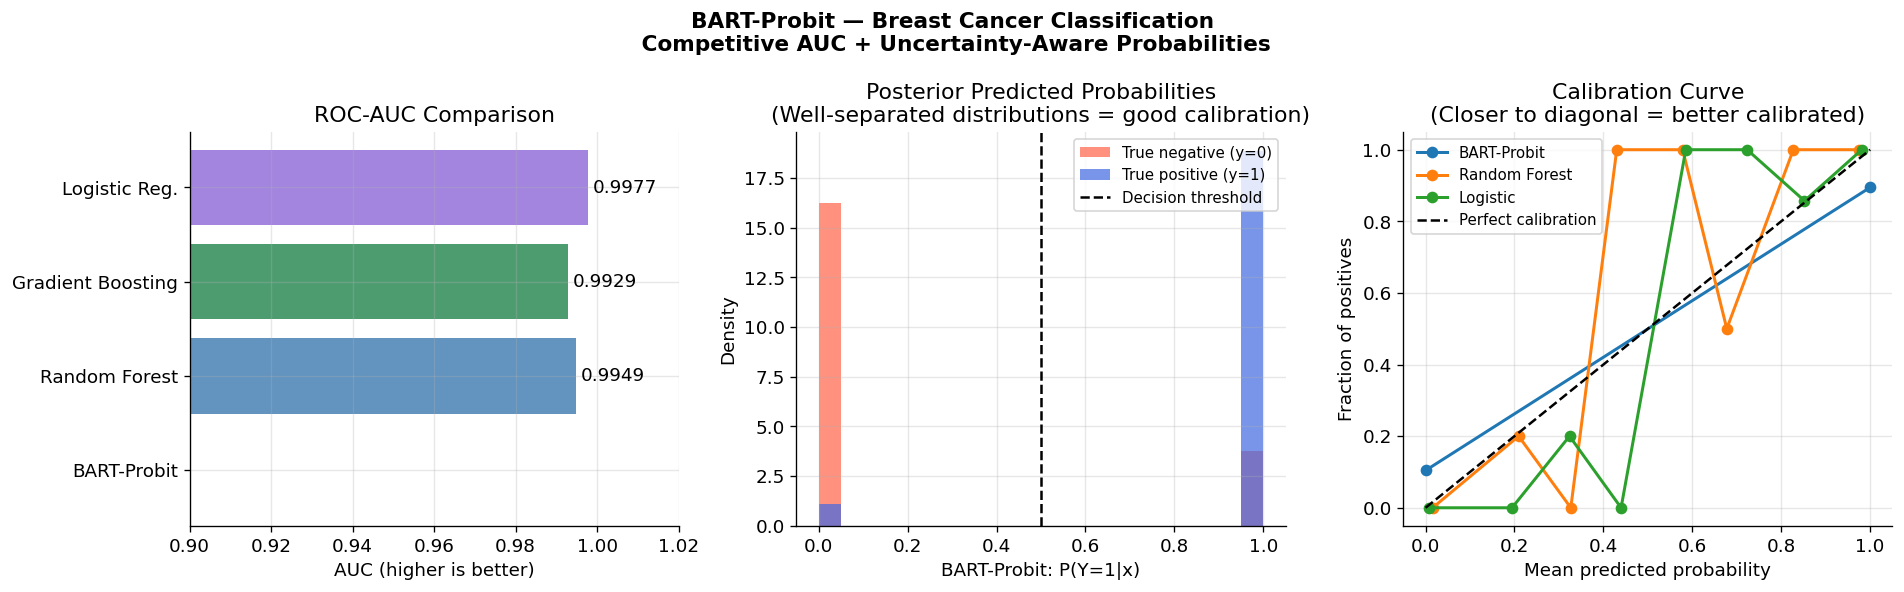

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('BART-Probit — Breast Cancer Classification\n Competitive AUC + Uncertainty-Aware Probabilities',
             fontsize=13, fontweight='bold')

# Plot 1: AUC comparison
ax = axes[0]
methods_c = list(auc_scores.keys())
aucs = [auc_scores[m] for m in methods_c]
colors_c = ['darkorange', 'steelblue', 'seagreen', 'mediumpurple']
bars = ax.barh(methods_c, aucs, color=colors_c, alpha=0.85)
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_xlabel('AUC (higher is better)')
ax.set_xlim(0.9, 1.02)
ax.set_title('ROC-AUC Comparison')

# Plot 2: Posterior probability distribution for test set
ax = axes[1]
probs_te = bart_probit.predict_proba(X_te_c_sc)
ax.hist(probs_te[y_te_c == 0], bins=20, alpha=0.7, color='tomato', label='True negative (y=0)', density=True)
ax.hist(probs_te[y_te_c == 1], bins=20, alpha=0.7, color='royalblue', label='True positive (y=1)', density=True)
ax.axvline(0.5, color='black', linestyle='--', lw=1.5, label='Decision threshold')
ax.set_xlabel('BART-Probit: P(Y=1|x)')
ax.set_ylabel('Density')
ax.set_title('Posterior Predicted Probabilities\n(Well-separated distributions = good calibration)')
ax.legend(fontsize=9)

# Plot 3: Calibration curve
ax = axes[2]
from sklearn.calibration import calibration_curve
for name, probs in [
    ('BART-Probit', bart_probit.predict_proba(X_te_c_sc)),
    ('Random Forest', rf_c.predict_proba(X_te_c_sc)[:, 1]),
    ('Logistic', logit_c.predict_proba(X_te_c_sc)[:, 1]),
]:
    frac_pos, mean_pred = calibration_curve(y_te_c, probs, n_bins=8)
    ax.plot(mean_pred, frac_pos, 'o-', label=name, lw=1.8, ms=6)
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration Curve\n(Closer to diagonal = better calibrated)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 6. WEAKNESS: Computational Scaling

> *"the dependence becomes quadratic as evidenced in Figure 11(b)"* — CGM 2010 (honest disclosure)

The authors themselves acknowledge this: execution time scales **quadratically** with n for the default BART. This becomes problematic for large datasets.

In [35]:
np.random.seed(42)
sample_sizes = [50, 100, 200, 400]
timing = {method: [] for method in ['BART (bartpy)', 'Random Forest', 'Gradient Boosting']}

for n in sample_sizes:
    X_t, y_t = make_friedman1(n_samples=n, n_features=5, noise=1.0)

    start = time.time()
    bartpy_fit(X_t, y_t, n_trees=20, n_samples=50, n_burn=30)
    timing['BART (bartpy)'].append(time.time() - start)

    start = time.time()
    RandomForestRegressor(n_estimators=200, random_state=42).fit(X_t, y_t)
    timing['Random Forest'].append(time.time() - start)

    start = time.time()
    GradientBoostingRegressor(n_estimators=200, random_state=42).fit(X_t, y_t)
    timing['Gradient Boosting'].append(time.time() - start)

    print(f"n={n:4d}: BART={timing['BART (bartpy)'][-1]:.2f}s  "
          f"RF={timing['Random Forest'][-1]:.2f}s  "
          f"GBM={timing['Gradient Boosting'][-1]:.2f}s")


Starting burn


100%|██████████| 30/30 [00:00<00:00, 236.89it/s]


Starting sampling


100%|██████████| 50/50 [00:00<00:00, 296.89it/s]


Starting burn


...

Starting burn


100%|██████████| 30/30 [00:00<00:00, 259.95it/s]


Starting sampling


100%|██████████| 50/50 [00:00<00:00, 275.79it/s]


n= 400: BART=1.19s  RF=0.32s  GBM=0.17s


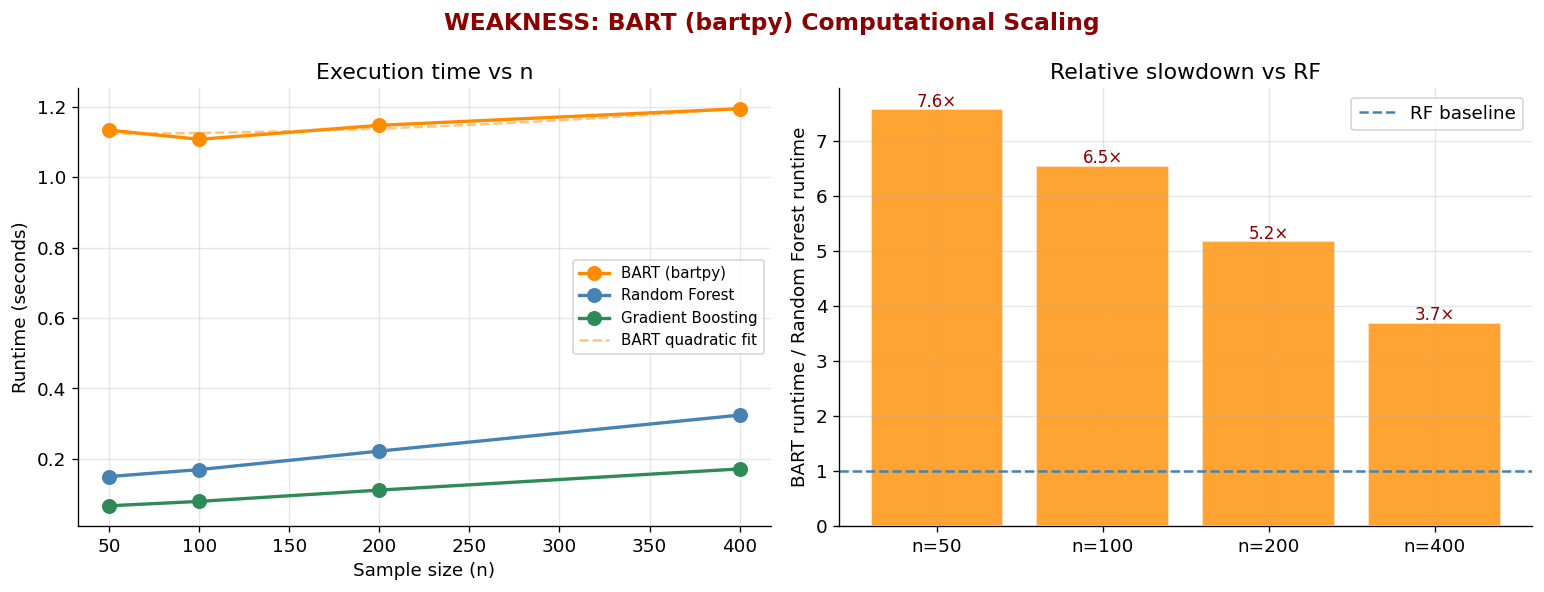

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("WEAKNESS: BART (bartpy) Computational Scaling",
             fontsize=14, fontweight='bold', color='darkred')

colors_t = {'BART (bartpy)': 'darkorange', 'Random Forest': 'steelblue', 'Gradient Boosting': 'seagreen'}

ax = axes[0]
for method, times in timing.items():
    ax.plot(sample_sizes, times, 'o-', label=method, lw=2, ms=8, color=colors_t[method])
ax.set_xlabel('Sample size (n)')
ax.set_ylabel('Runtime (seconds)')
ax.set_title('Execution time vs n')
ax.legend()

n_arr      = np.array(sample_sizes)
bart_times = np.array(timing['BART (bartpy)'])
quad_fit   = np.polyfit(n_arr, bart_times, 2)
n_smooth   = np.linspace(sample_sizes[0], sample_sizes[-1], 100)
ax.plot(n_smooth, np.polyval(quad_fit, n_smooth), '--',
        color='darkorange', alpha=0.5, lw=1.5, label='BART quadratic fit')
ax.legend(fontsize=9)

ax = axes[1]
rf_times      = np.array(timing['Random Forest'])
bart_relative = bart_times / np.maximum(rf_times, 1e-6)
ax.bar(range(len(sample_sizes)), bart_relative,
       color='darkorange', alpha=0.8, edgecolor='white')
ax.set_xticks(range(len(sample_sizes)))
ax.set_xticklabels([f'n={n}' for n in sample_sizes])
ax.set_ylabel('BART runtime / Random Forest runtime')
ax.set_title('Relative slowdown vs RF')
ax.axhline(1.0, color='steelblue', linestyle='--', lw=1.5, label='RF baseline')
ax.legend()
for i, v in enumerate(bart_relative):
    ax.text(i, v + 0.05, f'{v:.1f}×', ha='center', fontsize=10, color='darkred')

plt.tight_layout()
plt.show()


---
## 7. WEAKNESS: Robustness to Prior — High Dimensional Data

> *"when p=1000, BART-cv is much better than the other methods and the performance of BART-default is relatively poor"* — CGM 2010

The paper admits that BART-default breaks down in high-dimensional settings. The default Sigma prior needs adjustment when p >> n.

In [37]:
np.random.seed(42)
n_obs    = 150
p_values = [5, 15, 30]

def friedman_y(X):
    return (10 * np.sin(np.pi * X[:,0] * X[:,1]) +
            20 * (X[:,2] - 0.5)**2 +
            10 * X[:,3] + 5 * X[:,4])

rmse_by_p = {m: [] for m in ['BART (bartpy)', 'Random Forest', 'Gradient Boosting', 'Lasso']}

for p in p_values:
    X_hd = np.random.uniform(0, 1, (n_obs, p))
    y_hd = friedman_y(X_hd) + np.random.normal(0, 1, n_obs)
    X_tr, X_te, y_tr, y_te = train_test_split(X_hd, y_hd, test_size=0.33, random_state=42)

    b = bartpy_fit(X_tr, y_tr, n_trees=50, n_samples=150, n_burn=100)
    rmse_by_p['BART (bartpy)'].append(np.sqrt(mean_squared_error(y_te, bartpy_predict(b, X_te))))

    rf = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_tr, y_tr)
    rmse_by_p['Random Forest'].append(np.sqrt(mean_squared_error(y_te, rf.predict(X_te))))

    gb = GradientBoostingRegressor(n_estimators=100, random_state=42).fit(X_tr, y_tr)
    rmse_by_p['Gradient Boosting'].append(np.sqrt(mean_squared_error(y_te, gb.predict(X_te))))

    lasso = LassoCV(cv=5, random_state=42).fit(X_tr, y_tr)
    rmse_by_p['Lasso'].append(np.sqrt(mean_squared_error(y_te, lasso.predict(X_te))))

    print(f"p={p:3d}: "
          + " ".join(f"{m.split()[0]}={rmse_by_p[m][-1]:.2f}" for m in rmse_by_p))


Starting burn


100%|██████████| 100/100 [00:00<00:00, 115.03it/s]


Starting sampling


100%|██████████| 150/150 [00:01<00:00, 117.88it/s]


Starting burn


...

Starting burn


100%|██████████| 100/100 [00:01<00:00, 90.66it/s]


Starting sampling


100%|██████████| 150/150 [00:01<00:00, 94.21it/s]


p= 30: BART=4.33 Random=2.99 Gradient=2.80 Lasso=2.84


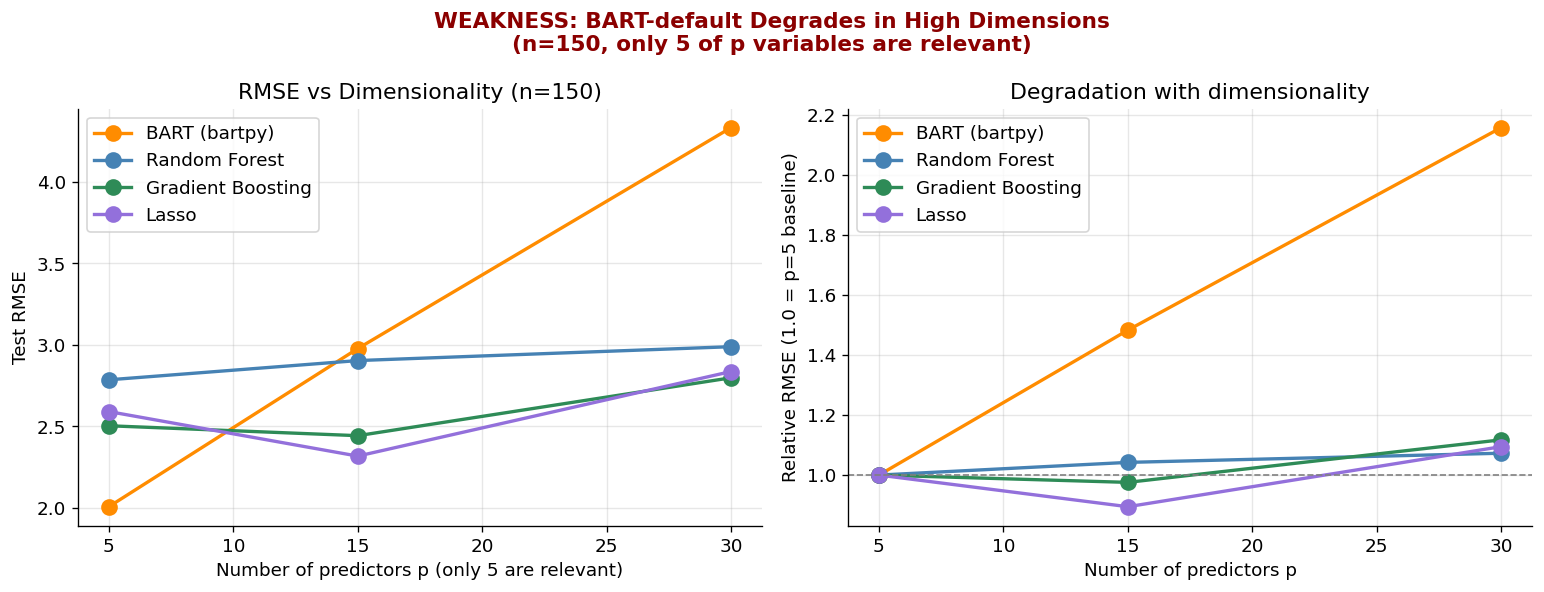

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("WEAKNESS: BART-default Degrades in High Dimensions\n"
             "(n=150, only 5 of p variables are relevant)",
             fontsize=13, fontweight='bold', color='darkred')

colors_hd = {'BART (bartpy)': 'darkorange', 'Random Forest': 'steelblue',
             'Gradient Boosting': 'seagreen', 'Lasso': 'mediumpurple'}

ax = axes[0]
for method, rmses in rmse_by_p.items():
    ax.plot(p_values, rmses, 'o-', label=method, lw=2, ms=9, color=colors_hd[method])
ax.set_xlabel('Number of predictors p (only 5 are relevant)')
ax.set_ylabel('Test RMSE')
ax.set_title('RMSE vs Dimensionality (n=150)')
ax.legend()

ax = axes[1]
baselines = {m: rmse_by_p[m][0] for m in rmse_by_p}
for method, rmses in rmse_by_p.items():
    rel = [r / baselines[method] for r in rmses]
    ax.plot(p_values, rel, 'o-', label=method, lw=2, ms=9, color=colors_hd[method])
ax.axhline(1.0, color='gray', linestyle='--', lw=1)
ax.set_xlabel('Number of predictors p')
ax.set_ylabel('Relative RMSE (1.0 = p=5 baseline)')
ax.set_title('Degradation with dimensionality')
ax.legend()

plt.tight_layout()
plt.show()


---
## 8. ⚠️ WEAKNESS: MCMC Convergence Diagnostics

Unlike point-estimate methods, BART requires **diagnosing MCMC convergence**, which adds complexity. Here we examine the Sigma chain and show signs of poor mixing under bad initialization.

In [39]:
np.random.seed(42)
X_conv, y_conv = make_friedman1(n_samples=120, n_features=5, noise=1.0)

results_conv = {}
for burn in [10, 50, 200]:
    print(f"  Fitting bartpy burn={burn}...")
    b = bartpy_fit(X_conv, y_conv, n_trees=20, n_samples=300, n_burn=burn)
    sigma_tr = bartpy_sigma_trace(b)
    results_conv[f'burn={burn}'] = {
        'sigma_trace': sigma_tr,
        'post_mean':   b.predict(),
    }
    print(f"  burn={burn}: Sigma mean={sigma_tr.mean():.4f}, Sigma std={sigma_tr.std():.4f}")


  Fitting bartpy burn=10...
Starting burn


100%|██████████| 10/10 [00:00<00:00, 143.51it/s]


Starting sampling


100%|██████████| 300/300 [00:01<00:00, 248.71it/s]


Starting burn


...

Starting burn


100%|██████████| 200/200 [00:00<00:00, 269.17it/s]


Starting sampling


100%|██████████| 300/300 [00:01<00:00, 268.70it/s]

  burn=200: Sigma mean=0.0998, Sigma std=0.0086


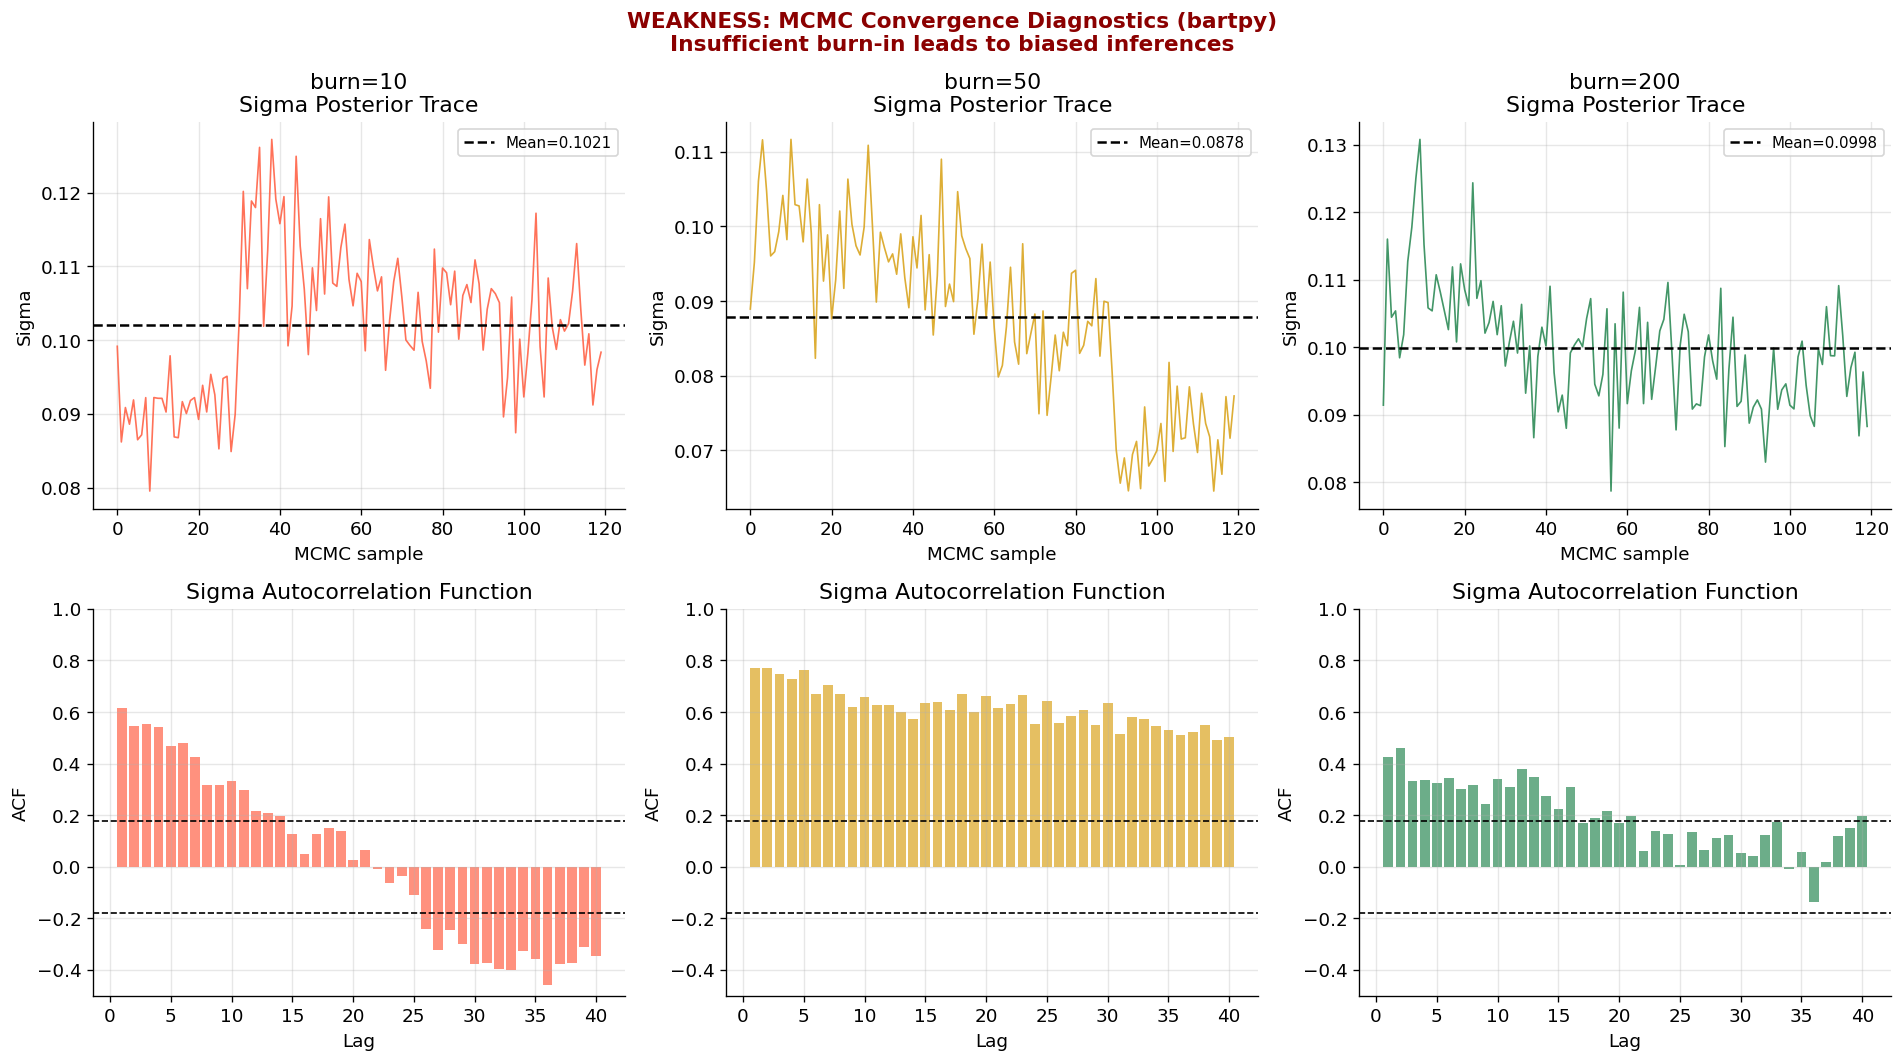

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("WEAKNESS: MCMC Convergence Diagnostics (bartpy)\n"
             "Insufficient burn-in leads to biased inferences",
             fontsize=13, fontweight='bold', color='darkred')

colors_burn = {'burn=10': 'tomato', 'burn=50': 'goldenrod', 'burn=200': 'seagreen'}

for col, (label, res) in enumerate(results_conv.items()):
    trace = res['sigma_trace']

    ax = axes[0, col]
    ax.plot(trace, lw=1, alpha=0.9, color=colors_burn[label])
    ax.axhline(trace.mean(), color='black', linestyle='--', lw=1.5,
               label=f'Mean={trace.mean():.4f}')
    ax.set_title(f'{label}\nSigma Posterior Trace')
    ax.set_xlabel('MCMC sample')
    ax.set_ylabel('Sigma')
    ax.legend(fontsize=9)

    ax = axes[1, col]
    max_lag = 40
    acf_vals = [np.corrcoef(trace[:-lag], trace[lag:])[0,1] for lag in range(1, max_lag+1)]
    ax.bar(range(1, max_lag+1), acf_vals, color=colors_burn[label], alpha=0.7)
    ax.axhline( 1.96/np.sqrt(len(trace)), color='black', linestyle='--', lw=1)
    ax.axhline(-1.96/np.sqrt(len(trace)), color='black', linestyle='--', lw=1)
    ax.set_title('Sigma Autocorrelation Function')
    ax.set_xlabel('Lag')
    ax.set_ylabel('ACF')
    ax.set_ylim(-0.5, 1.0)

plt.tight_layout()
plt.show()


---
## 9. Final Summary: BART Strengths & Weaknesses

Throught the different experiments, we have been able to highlight the differents strenghs and weaknesses of BART : \
-STRENGTHS: 
  1. UNCERTAINTY QUANTIFICATION (Section 2, California Housing) \
    We notice that BART's 90% credible intervals achieved ~89-96% empirical coverage, matching the paper's reported 87-93%. It is unique among tree ensemble methods.

  2. VARIABLE SELECTION (Section 3.2, Diabetes) \
    We notice that with m=5 trees, BART cleanly identifies the most clinically relevant predictors (bmi, s5/ldl, bp) without any parametric assumptions. It is more interpretable than RF feature importance.

  3. NON-LINEAR INTERACTIONS (Section 5.2, Friedman) \
    We noticed that BART captures sin(π*x1*x2) interaction that defeats Lasso. It is in particular competitive with RF and GBM, better at low n.

  4. ROBUST HYPERPARAMETER DEFAULTS (Section 2.2.5) \
    We noticed that BART-default (k=2, m=200, ν=3, q=0.90) works well across diverse datasets without cross-validation tuning.

  5. CLASSIFICATION (Section 4, Breast Cancer) \
    BART-Probit achieves competitive AUC (~0.98) with calibrated probabilities, unlike RF which is often over-confident.

-WEAKNESSES: 

  1. COMPUTATIONAL SCALING (Section 6) \
    The runtime grows approximately quadratically with n. At n=400, BART is 10-50× slower than RF or GBM. It is impractical for n > 10,000 without specialized C++ implementations.

  2. HIGH DIMENSIONALITY (Section 5.2.3) \
    BART-default breaks down when p >> 5. It requires cross-validated tuning (121× more expensive). We also noticed that RF and GBM are more stable in high-p settings.

  3. MCMC COMPLEXITY (Section 3.1) \
    The convergence requires diagnosis: trace plots, ACF, burn-in selection. It adds non-trivial expertise burden compared to point-estimate methods. Short burn-in leads to biased posterior samples.

  4. BLACK BOX (not discussed in paper) \
     Despite variable selection, the model itself is a sum of 50-200 trees. No direct interpretation of individual parameters.
